<a href="https://colab.research.google.com/github/MrCherveN/Machine-Learning--4-0_HomeTasks/blob/main/HW_NLP_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнє завдання: Побудова класифікатора сентименту на основі набору даних Tweet Sentiment Extraction

**Мета:** Провести аналіз набору даних, виконати векторизацію текстових даних за допомогою методів bag-of-words та TF-IDF, порівняти їх, побудувати класифікатор та провести аналіз помилок.

**Набір даних:**
Дані беремо з цього змагання на Kaggle: https://www.kaggle.com/competitions/tweet-sentiment-extraction/data?select=train.csv


Якщо не вдається завантажиит з Kaggle, ось тут можна - https://drive.google.com/file/d/1kfu5zCRsDHxoBZigBlGIcCieKlws02HT/view?usp=sharing

Оригінальне змагання має дещо іншу задачу, але ми будемо поки будувати саме класифікатор.

Увага! В цьому наборі завдань для простоти експериментів ми будемо спочатку робити векторизацію на всьому наборі даних, а потім розбивку на train i test. В робочих проєктах ми теж можемо використати цей підхід для швидшої побудови PoC (proof of concept). Але фінальне рішення, яке ми будемо деплоїти - треба проводити за правилом - спочатку розбивка на трейн і тест, потім пишемо обробку для трейну, навчаємо векторизатори. І потім використовуємо готові векторизатори для тесту і всіх даних на етапі передбачення (інференсу).

### Завдання 1. Завантаження та ознайомлення з набором даних

- Завантажте набір даних `train.csv` з посилання та ознайомтеся з його структурою.
- Виведіть перші 5 рядків та основну статистику: кількість записів, типи колонок, кількість пропущених значень.
- Видаліть записи, в яких є пропущені значення.



In [1]:
import pandas as pd

In [2]:
train_fname = 'tweet_sentiment_train.csv.zip'
raw_df = pd.read_csv(train_fname)

In [3]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27481 entries, 0 to 27480
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   textID         27481 non-null  object
 1   text           27480 non-null  object
 2   selected_text  27480 non-null  object
 3   sentiment      27481 non-null  object
dtypes: object(4)
memory usage: 858.9+ KB


In [4]:
raw_df.head()

,textID,text,selected_text,sentiment
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative
2,088c60f138,my boss is bullying me...,bullying me,negative
3,9642c003ef,what interview! leave me alone,leave me alone,negative
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative


In [5]:
raw_df.dropna(inplace=True)

In [6]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 27480 entries, 0 to 27480
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   textID         27480 non-null  object
 1   text           27480 non-null  object
 2   selected_text  27480 non-null  object
 3   sentiment      27480 non-null  object
dtypes: object(4)
memory usage: 1.0+ MB


### Завдання 2. Exploratory Data Analysis

- Проведіть аналіз кількості класів та розподілу міток. Класи знаходяться в колонці `sentiment`.
- Візуалізуйте розподіл довжин текстів в символах та зробіть висновок про довжини постів: якої довжини постів найбільше, що бачите з розподілу?



In [7]:
raw_df.sentiment.value_counts()

,count
sentiment,
neutral,11117
positive,8582
negative,7781


In [8]:
raw_df.sentiment.value_counts(normalize=True)

,proportion
sentiment,
neutral,0.404549
positive,0.312300
negative,0.283151


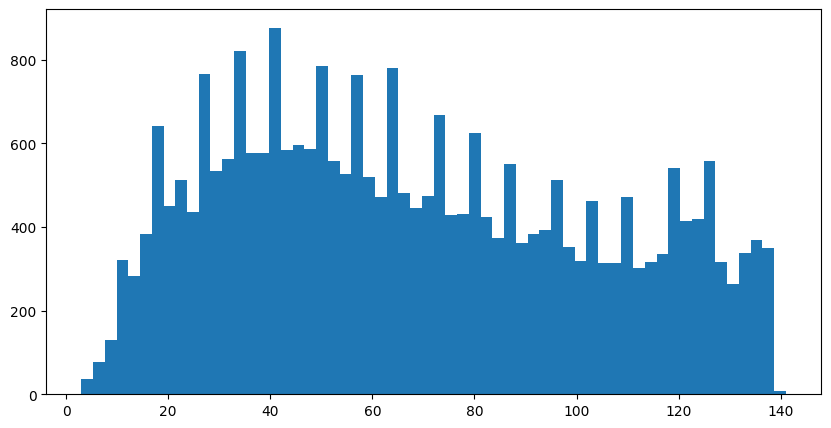

In [9]:
import matplotlib.pyplot as plt
docs_len = [len(doc) for doc in raw_df.text]
plt.figure(figsize=(10, 5))
plt.hist(docs_len, bins=60)
plt.show();

***Висновки:***
- Основна маса постів зосереджена в діапазоні 20–80 символів, з найгустішою частиною навколо 30–70 символів.
- Спостерігаються аномальні різкі пікові значення (наприклад в районі 40 символів).   
- Розподіл поступово спадає після 80 символів та майже зникає після 130.

### Завдання 3. Попередня обробка текстових даних та векторизація з bag of words


Наша задача тут отримати вектори методом bag of words колонки `text`, виконавши попередню обробку тексту.
Попередня обробка має включати
- видалення stopwords необхідної мови
- токенізація (розбиття текстів на фрагменти по 1 слову)
- стеммінг слів зі `SnowballStemmer`.
- самостійно задайте кількість слів в словнику для `sklearn.feature_extraction.text.CountVectorizer`. Можливо для цього доведеться виконати додатковий аналіз.

Ви також можете додати сюди додаткові методи очистки текстів, наприклад, видалення деяких символів чи груп символів, якщо в процесі роботи побачите, що хочете щось видалити.

Напишіть код аби виконати це завдання. Перед цим рекомендую детально ознайомитись з тим, що робить обʼєкт `sklearn.feature_extraction.text.CountVectorizer` за замовченням.

Це завдання можна виконати двома способами - один - максимально подібно до того, як ми це робили в лекції, другий - дещо інакше перегрупувавши етапи обробки тексту.




In [10]:
from sklearn.feature_extraction.text import CountVectorizer
import nltk
from nltk.tokenize import word_tokenize
from nltk.stem.snowball import SnowballStemmer
from nltk.corpus import stopwords
import re

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')
english_stopwords = stopwords.words('english')
stemmer = SnowballStemmer(language='english')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [11]:
def tokenize(text):

    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text) # посилання
    text = re.sub(r"[^a-z\s'\*]", " ", text) # залишити текст та символ "*"

    tokens = word_tokenize(text)
    return [stemmer.stem(word) for word in tokens if len(word) > 1 and word not in english_stopwords]

In [12]:
vectorizer_bow = CountVectorizer(tokenizer=tokenize,
                                 max_features=3000,
                                 token_pattern = None)
vectorizer_bow.fit(raw_df.text)

CountVectorizer(max_features=3000, token_pattern=None,
                tokenizer=<function tokenize at 0x79a4595acb80>)

In [13]:
print(len(vectorizer_bow.vocabulary_))

3000


In [14]:
vectorizer_bow.get_feature_names_out()[:100]

array(['abandon', 'abil', 'abl', 'absolut', 'abt', 'ac', 'academi',
       'accept', 'access', 'accid', 'accident', 'accomplish', 'accord',
       'account', 'ace', 'ach', 'achiev', 'ack', 'across', 'act',
       'action', 'activ', 'actual', 'ad', 'adam', 'add', 'addict',
       'address', 'admit', 'adopt', 'ador', 'adult', 'advanc', 'advantag',
       'adventur', 'advic', 'afford', 'afraid', 'afternoon', 'afterward',
       'age', 'ago', 'agre', 'ah', 'aha', 'ahaha', 'ahead', 'ahh', 'ahhh',
       'ahhhh', 'ahhhhh', 'aight', 'aim', 'aint', 'air', 'airport', 'aka',
       'al', 'ala', 'alarm', 'album', 'alcohol', 'alex', 'alic', 'alien',
       'aliv', 'allah', 'allen', 'allerg', 'allergi', 'allow', 'almost',
       'alon', 'along', 'alot', 'alreadi', 'alright', 'also', 'altern',
       'although', 'alway', 'amaz', 'amazon', 'amber', 'america',
       'american', 'ami', 'amount', 'amus', 'andi', 'andrew', 'ang',
       'angel', 'angri', 'anim', 'ankl', 'ann', 'anna', 'anniversari',
   

In [15]:
X_bow = vectorizer_bow.transform(raw_df.text)
X_bow.shape

(27480, 3000)

In [16]:
X_bow[0].toarray()

array([[0, 0, 0, ..., 0, 0, 0]])

### Завдання 4. Побудова класифікатора

- Розділіть індекси даних на навчальний та тестовий набори в обраному співвівдношенні. Використовуючи отримані індекси сфомуйте набори для тренування класифікатора `X_train_bow, X_test_bow, y_train, y_test`.
- Навчіть класифікатор (наприклад, Logistic Regression, Decision Tree або один з алгоритмів бустингу) на даних, векторизованих методом bag-of-words. Спробуйте кілька моделей і оберіть найбільш точну :)
- Виведіть інформацію, яка дає можливість оцінити якість класифікації.
- Оцініть якість фінальної класифікації: вона хороша чи не дуже?



In [17]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, f1_score, roc_auc_score, roc_curve
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.tree import DecisionTreeClassifier

train_idx, test_idx = train_test_split(
    np.arange(len(raw_df)),
    test_size=0.3,
    random_state=42,
    stratify=raw_df.sentiment
)

X_train_bow = X_bow[train_idx]
X_test_bow  = X_bow[test_idx]
y_train = raw_df.sentiment.iloc[train_idx]
y_test = raw_df.sentiment.iloc[test_idx]


In [18]:
# Logistic Regression
MAX_ITER = 1000
model_reg = LogisticRegression(max_iter=MAX_ITER,
                           solver='saga',
                           random_state=42)

model_reg.fit(X_train_bow, y_train)
train_preds = model_reg.predict(X_train_bow)
test_preds = model_reg.predict(X_test_bow)

print("classification report for Train - Logistic Regression (bow):")
print(classification_report(y_train, train_preds))

print("classification report for Test - Logistic Regression (bow):")
print(classification_report(y_test, test_preds))

classification report for Train - Logistic Regression (bow):
              precision    recall  f1-score   support

    negative       0.82      0.73      0.77      5447
     neutral       0.75      0.83      0.79      7782
    positive       0.84      0.81      0.83      6007

    accuracy                           0.79     19236
   macro avg       0.80      0.79      0.79     19236
weighted avg       0.80      0.79      0.79     19236

classification report for Test - Logistic Regression (bow):
              precision    recall  f1-score   support

    negative       0.70      0.61      0.66      2334
     neutral       0.63      0.72      0.67      3335
    positive       0.75      0.70      0.72      2575

    accuracy                           0.68      8244
   macro avg       0.70      0.68      0.68      8244
weighted avg       0.69      0.68      0.68      8244



In [19]:
pd.Series(train_preds).value_counts()

,count
neutral,8676
positive,5753
negative,4807


In [20]:
pd.Series(y_train).value_counts()

,count
sentiment,
neutral,7782
positive,6007
negative,5447


In [21]:
# Decision Tree

# from sklearn.model_selection import GridSearchCV
# from sklearn.tree import DecisionTreeClassifier

# param_grid = {
#     'max_depth': range(1, 50)
# }

# grid = GridSearchCV(
#     DecisionTreeClassifier(random_state=42),
#     param_grid,
#     cv=5,
#     scoring='f1_macro'
# )

# grid.fit(X_train_bow, y_train)

# print(grid.best_params_)
# print(grid.best_score_)

In [22]:
model_tree = DecisionTreeClassifier(
    max_depth=49,
    random_state=42
)

model_tree.fit(X_train_bow, y_train)

train_preds_tree = model_tree.predict(X_train_bow)
test_preds_tree = model_tree.predict(X_test_bow)


print("classification report for Train - Decision Tree (bow):")
print(classification_report(y_train, train_preds_tree))


print("classification report for Test - Decision Tree (bow):")
print(classification_report(y_test, test_preds_tree))


classification report for Train - Decision Tree (bow):
              precision    recall  f1-score   support

    negative       0.96      0.53      0.68      5447
     neutral       0.65      0.95      0.77      7782
    positive       0.92      0.75      0.83      6007

    accuracy                           0.77     19236
   macro avg       0.84      0.74      0.76     19236
weighted avg       0.82      0.77      0.76     19236

classification report for Test - Decision Tree (bow):
              precision    recall  f1-score   support

    negative       0.76      0.43      0.54      2334
     neutral       0.58      0.82      0.68      3335
    positive       0.77      0.66      0.71      2575

    accuracy                           0.66      8244
   macro avg       0.70      0.64      0.64      8244
weighted avg       0.69      0.66      0.65      8244



***Висновок:***
- Серед розглянутих моделей найкраще себе показала модель Logistic Regression. Вона продемонструвала вищі показники якості класифікації порівняно з Decision Tree.
- Слід зазначити, що модель Logistic Regression демонструє середню якість класифікації з ознаками перенавчання: значення F1-score становить 0.79 на тренувальному наборі та 0.68 на тестовому. Також, згідно з classification report, модель найкраще класифікує клас positive, а найгірше - negative.

### Завдання 5. Аналіз впливовості слів в отриманого класифікатора

- Для обраної вами моделі проведіть аналіз важливості слів (ознак): які слова (токени) найбільше впливають для визначення сентименту? Чи це логічно на ваш погляд, що саме ці символи впливають найбільше/найменще?


In [23]:
feature_importance_bow = pd.Series(model_reg.coef_[0], index=vectorizer_bow.get_feature_names_out(), name='importance_bow').sort_values(ascending=False)
feature_importance_bow

,importance_bow
sad,2.558437
suck,2.452589
sorri,2.406976
hate,2.303734
bore,2.283289
...,...
beauti,-1.903420
thank,-1.931498
love,-2.155767
glad,-2.278729


In [24]:
feature_importance_bow[:15]

,importance_bow
sad,2.558437
suck,2.452589
sorri,2.406976
hate,2.303734
bore,2.283289
fail,2.119248
worst,2.118230
miss,2.094648
stupid,2.069713
terribl,2.044598


In [25]:
raw_df[raw_df['text'].str.contains('miss', case=False, na=False)]

,textID,text,selected_text,sentiment
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative
18,af3fed7fc3,is back home now gonna miss every one,onna,negative
36,2724775d6b,Born and raised in NYC and living in Texas for...,miss,negative
76,35f393a245,"WOW, i AM REALLY MiSSiN THE FAM(iLY) TODAY. BA...",BADDD.,negative
87,cd0d522bb1,His snoring is so annoying n it keeps me from ...,His snoring is so annoying n it keeps me from ...,neutral
...,...,...,...,...
27349,f60f20ed09,"yea but that`s an old pic, she looks a lot d...","yea but that`s an old pic, she looks a lot di...",neutral
27363,a232d645c7,Stu Lantz is awesome! I miss Chick Hearn tho,Stu Lantz is awesome! I miss Chick Hearn tho,neutral
27403,ccbb209dd6,My Friday made me miss high school,me miss high school,negative
27426,132e051fe8,my cousins moved there like 2 years ago and ...,m sad,negative


In [26]:
feature_importance_bow[-15:]

,importance_bow
prefer,-1.423441
excit,-1.462926
hope,-1.469429
nice,-1.526748
enjoy,-1.610300
welcom,-1.626719
great,-1.654826
amaz,-1.687008
cute,-1.698517
congrat,-1.709099


***Висновок:***
- Отримані результати виглядають логічними, оскільки слова з негативним емоційним забарвленням мають найбільший позитивний коефіцієнт для негативного класу.

- Аналогічно слова з позитивним забарвленням найбільше впливають на позитивний клас.

### Завдання 6. Векторизація текстів з допомогою TF-IDF. Тренування класифікатора, аналіз точності і впливовості слів.

- Проведіть векторизацію текстів з векторизатором TfidfVectorizer. Реалізуйте векторизацію так, аби препроцесинг включав всі ті самі кроки, що і в випадку використання векторизації Bag of Words.

- Натренуйте той самий класифікатор на TF-IDF векторах, виконавши розбивку набору даних на train, test так, аби в трейні були всі ті самі записи, що і були в попередньому завданні (це важливо для порівняння результатів).

- Проаналізуйте якість класифікації вивівши потрібні для цього метрики. Чи стала якість класифікації кращою?

- Які токени найбільше впливають на результат при тренуваннні класифікатора з TF-IDF векторами? Порівняйте з найважливішими токенами при Bag of Words векторизації. Яку векторизацію ви б обрали для фінальної імплементації рішення? Обґрунтуйте свій вибір.



In [27]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(tokenizer = tokenize, max_features = 3000, token_pattern = None)

X_tfidf = tfidf_vectorizer.fit_transform(raw_df.text)

X_train_tfidf = X_tfidf[train_idx]
X_test_tfidf  = X_tfidf[test_idx]


In [28]:
model_tfidf = LogisticRegression(max_iter=MAX_ITER,
                                solver='saga',
                                random_state=42)

model_tfidf.fit(X_train_tfidf, y_train)

train_preds_tfidf = model_tfidf.predict(X_train_tfidf)
test_preds_tfidf = model_tfidf.predict(X_test_tfidf)

print("classification report for Train Logistic Regression (TF-IDF):")
print(classification_report(y_train, train_preds_tfidf))

print("classification report for Test Logistic Regression (TF-IDF):")
print(classification_report(y_test, test_preds_tfidf))

classification report for Train Logistic Regression (TF-IDF):
              precision    recall  f1-score   support

    negative       0.81      0.68      0.74      5447
     neutral       0.70      0.82      0.76      7782
    positive       0.83      0.77      0.80      6007

    accuracy                           0.77     19236
   macro avg       0.78      0.76      0.77     19236
weighted avg       0.77      0.77      0.77     19236

classification report for Test Logistic Regression (TF-IDF):
              precision    recall  f1-score   support

    negative       0.72      0.59      0.65      2334
     neutral       0.62      0.75      0.68      3335
    positive       0.77      0.69      0.73      2575

    accuracy                           0.69      8244
   macro avg       0.70      0.68      0.68      8244
weighted avg       0.70      0.69      0.69      8244



In [29]:
pd.Series(train_preds_tfidf).value_counts()

,count
neutral,9097
positive,5547
negative,4592


In [30]:
pd.Series(y_train).value_counts()

,count
sentiment,
neutral,7782
positive,6007
negative,5447


In [31]:
feature_importance_tfidf = pd.Series(model_tfidf.coef_[0], index=tfidf_vectorizer.get_feature_names_out(), name='importance_tfidf').sort_values(ascending=False)
feature_importance_tfidf

,importance_tfidf
sad,4.918093
miss,4.638589
sorri,4.450049
hate,4.304277
suck,4.055847
...,...
glad,-3.083254
hope,-3.161457
awesom,-3.257138
thank,-3.671559


In [32]:
feature_importance_tfidf[:15]

,importance_tfidf
sad,4.918093
miss,4.638589
sorri,4.450049
hate,4.304277
suck,4.055847
bore,3.650825
fail,3.494612
sick,3.222272
stupid,3.197053
tire,3.123435


In [33]:
raw_df[raw_df['text'].str.contains('sad', case=False, na=False)]

,textID,text,selected_text,sentiment
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative
116,401869d615,graduation is done im a little sad.. anyone w...,sad.,negative
133,504539e6ec,why are you sad?,sad?,negative
143,254546cd2c,What`s sad is that I actually had to google t...,"That sucks, tho.",negative
183,8407ac30b0,I`m sad that I missed you guys last night!,sad,negative
...,...,...,...,...
27093,abcb83a4c1,I know! I can`t go either...it`s sad She nee...,sad,negative
27171,eaf61e92a4,"I`ve been to Rome, Italy. I love it there. Ele...","I`ve been to Rome, Italy. I love it there. Ele...",neutral
27240,40143b692e,who knows It makes me sad lol,e sad,negative
27364,946f23739a,so sad emma u sad to be leaving the show? ****,so sad,negative


In [34]:
feature_importance_tfidf[-15:]

,importance_tfidf
best,-1.899794
excit,-1.909303
cool,-1.948192
welcom,-1.951026
cute,-2.037107
better,-2.099116
enjoy,-2.174248
amaz,-2.237902
nice,-2.315735
great,-2.871556


***Висновок:***
- TF-IDF не забезпечив значного покращення якості. Отримані результати показали, що якість класифікації залишається приблизно на рівні Bag of Words: F1-score становить 0.77 на тренувальному наборі та 0.68 на тестовому.  
- Порівнюючи основні токени у моделях на основі Bag of Words та TF-IDF можна помітити, що набір ключових слів є дуже схожим. Хоча також можна відмітити деякі відмінності, які ймовірно, викликані різними підходами визначення вагомості окремим словам.
- Для фінальної імплементації я б обрав TF-IDF оскільки:

      - модель має менший геп по перенавчанню між train та test (9%);
      - модель зменшує вплив частих малоінформативних слів;
      - збільшує вагу специфічних слів.
    

### Завдання 7. Аналіз помилок класифікації з векторизацією TF-IDF.

- Проаналізуйте, на яких екземплярах помиляється класифікатор при векторизації TF-IDF.
- На основі аналізу запропонуйте 3 шляхи поліпшення якості класифікації.

In [35]:
df = raw_df.iloc[test_idx].copy()

df['test_preds_tfidf'] = test_preds_tfidf
df['error'] = df['sentiment'] != df['test_preds_tfidf']

In [49]:
errors = df[df['error']]
errors.head(20)

,textID,text,selected_text,sentiment,test_preds_tfidf,error
2664,385e0fb48e,wearing a pair of trousers that were loose las...,tight this year,negative,neutral,True
7479,a82705a699,"Oh ok,Thanks.Dont know where the courthouse i...",t hates,negative,positive,True
27330,ef5c7bb3fa,"unfortunetly no I wish, I mean sometimes lik...",unfortunetly,negative,positive,True
26543,cdee7f473f,"Time to get ready for wrk! Ahhhh, I dnt wanna ...",I dnt wanna goooo!,negative,neutral,True
7190,f3f729c014,not so good,not so good,negative,positive,True
16377,8caf9852b4,bout tuh head out an find sum wher tuh go an c...,chill,positive,neutral,True
9239,7544811702,_precious06 sooo mad,_precious06 sooo mad,neutral,negative,True
3920,3cef251698,What? I focused on Tom so much I didn`t see my...,What? I focused on Tom so much I didn`t see my...,neutral,negative,True
13043,5802b869df,i have three hours to do my hair. and it STILL...,i have three hours to do my hair. and it STILL...,negative,neutral,True
5865,2334ec3a85,I assume you mean 2nd item with 3 nested line...,no invert call tree button to be found,negative,neutral,True


In [47]:
import random

np.random.seed(0)
for i in np.random.randint(0, len(errors), size=10):

    print(errors.iloc[i]["text"])
    print(f'\nsentiment: {errors.iloc[i]["sentiment"]}')
    print(f'test_preds_tfidf: {errors.iloc[i]["test_preds_tfidf"]}\n')
    print("=" *150)

getting ready for work. boohoohoo i dont wanna go to work!

sentiment: negative
test_preds_tfidf: neutral

is exhausted from a great weekend, and is looking forward to this week

sentiment: neutral
test_preds_tfidf: positive

just made DIY acid wash shorts! can`t wait to see what they look like

sentiment: neutral
test_preds_tfidf: positive

Off to rehearsal for the Rob DeLucca thingy next month. Nothing like learning new songs last minute

sentiment: neutral
test_preds_tfidf: positive

 Chocolate with peanut butter. One of my favorite combonations

sentiment: positive
test_preds_tfidf: neutral

just got out of the pool!!   so fun..now gonna watch tv and do stuff on the computer. (:

sentiment: positive
test_preds_tfidf: neutral

I was feeling guilty about buying a luxurious pair of shoes yesterday until my house mate just saw them and got over excited

sentiment: neutral
test_preds_tfidf: negative

Zach G. gets an extensive profile in this weekend`s NY Times Magazine. The chances of u

***Висновок:***
- Аналіз помилок показує, що основна частина помилок пов'язана з визначенням замість positive чи negative класу neutral.
 → neutral
- Спостерігається проблема некоректної інтерпретації конструкцій із запереченням.. Наприклад, "not a good" визначено як positive, хоча насправді це  negative.
- Модель не враховує контексту.


Для вирішення вищезазначених проблем варто:
- розглянути можливість використання n-грам;
- провести тюнінг гіперпараметрів моделі;
- застосувати інші більш потужні моделі обробки тексту.

І на фінал кернел для натхнення і ознайомлення з рішенням оригінальної задачі. Багато цікавих візуалізацій і аналізу є тут, а також тут розвʼязується саме проблема named entitty recognition і можна ознайомитись як це робиться - вона дещо складніша по своїй суті ніж класифікація, подумайте, чому:

https://www.kaggle.com/code/tanulsingh077/twitter-sentiment-extaction-analysis-eda-and-model